In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

print('all good')

all good


In [2]:
df = pd.read_csv("./TCS.csv")
df.columns = [c.strip().lower() for c in df.columns]
print(df.shape)
df.head()

(4139, 15)


,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
0,2004-08-25,TCS,EQ,850.00,1198.7,1198.7,979.00,985.00,987.95,1008.32,17116372,1.725876e+15,NaN,5206360,0.3042
1,2004-08-26,TCS,EQ,987.95,992.0,997.0,975.30,976.85,979.00,985.65,5055400,4.982865e+14,NaN,1294899,0.2561
2,2004-08-27,TCS,EQ,979.00,982.4,982.4,958.55,961.20,962.65,969.94,3830750,3.715586e+14,NaN,976527,0.2549
3,2004-08-30,TCS,EQ,962.65,969.9,990.0,965.00,986.40,986.75,982.65,3058151,3.005106e+14,NaN,701664,0.2294
4,2004-08-31,TCS,EQ,986.75,986.5,990.0,976.00,987.80,988.10,982.18,2649332,2.602133e+14,NaN,695234,0.2624


In [3]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

df = df.dropna(subset=['close'])
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.shape)

(4139, 15)


In [4]:
df['return_5d'] = df['close'].pct_change(5).shift(-5)

df['price_range'] = df['high'] - df['low']
df['prev_close']  = df['close'].shift(1)
df['daily_return']= df['close'].pct_change()
df['ma_5']        = df['close'].rolling(5).mean()
df['ma_20']       = df['close'].rolling(20).mean()
df['ma_ratio']    = df['ma_5'] / df['ma_20']
df['volatility']  = df['close'].rolling(5).std()
df['vol_change']  = df['volume'].pct_change()

df = df.dropna().reset_index(drop=True)
print(df.shape)

(4115, 24)


In [5]:
def label_signal(r):
    if r >= 0.02:
        return 'Buy'
    elif r <= -0.02:
        return 'Sell'
    else:
        return 'Neutral'

df['signal'] = df['return_5d'].apply(label_signal)

print(df['signal'].value_counts())
df[['close', 'return_5d', 'signal']].head(10)

signal
Neutral    1791
Buy        1315
Sell       1009
Name: count, dtype: int64


,close,return_5d,signal
0,1045.80,-0.028925,Sell
1,1052.05,-0.020009,Sell
2,1030.25,-0.003058,Neutral
3,1028.80,0.018371,Neutral
4,1020.75,0.054617,Buy
5,1015.55,0.064152,Buy
6,1031.00,0.049079,Buy
7,1027.10,0.068153,Buy
8,1047.70,0.048058,Buy
9,1076.50,0.022434,Buy


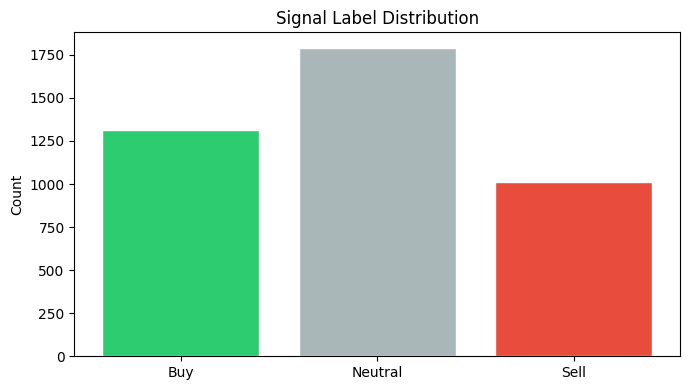

In [6]:
plt.figure(figsize=(7, 4))
order = ['Buy', 'Neutral', 'Sell']
counts = df['signal'].value_counts().reindex(order)
colors = ['#2ecc71', '#aab7b8', '#e74c3c']
plt.bar(counts.index, counts.values, color=colors, edgecolor='white')
plt.title('Signal Label Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [7]:
feature_cols = ['open', 'high', 'low', 'volume',
                'price_range', 'prev_close', 'daily_return',
                'ma_5', 'ma_20', 'ma_ratio', 'volatility', 'vol_change']

X = df[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(df['signal'])

print('Classes:', le.classes_)
print('X shape:', X.shape)
print('y shape:', y.shape)

Classes: ['Buy' 'Neutral' 'Sell']
X shape: (4115, 12)
y shape: (4115,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print('train:', len(X_train), '  test:', len(X_test))

train: 3292   test: 823


In [9]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest done')

Random Forest done


In [10]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print('XGBoost done')

XGBoost done


In [11]:
acc_rf  = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print('Random Forest Accuracy :', round(acc_rf, 4))
print('XGBoost Accuracy       :', round(acc_xgb, 4))

class_names = le.classes_

print('\n--- Random Forest Report ---')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

print('--- XGBoost Report ---')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

Random Forest Accuracy : 0.4557
XGBoost Accuracy       : 0.3913

--- Random Forest Report ---
              precision    recall  f1-score   support

         Buy       0.38      0.21      0.27       256
     Neutral       0.50      0.78      0.61       394
        Sell       0.19      0.08      0.11       173

    accuracy                           0.46       823
   macro avg       0.36      0.36      0.33       823
weighted avg       0.40      0.46      0.40       823

--- XGBoost Report ---
              precision    recall  f1-score   support

         Buy       0.31      0.23      0.26       256
     Neutral       0.49      0.58      0.53       394
        Sell       0.22      0.21      0.22       173

    accuracy                           0.39       823
   macro avg       0.34      0.34      0.34       823
weighted avg       0.38      0.39      0.38       823



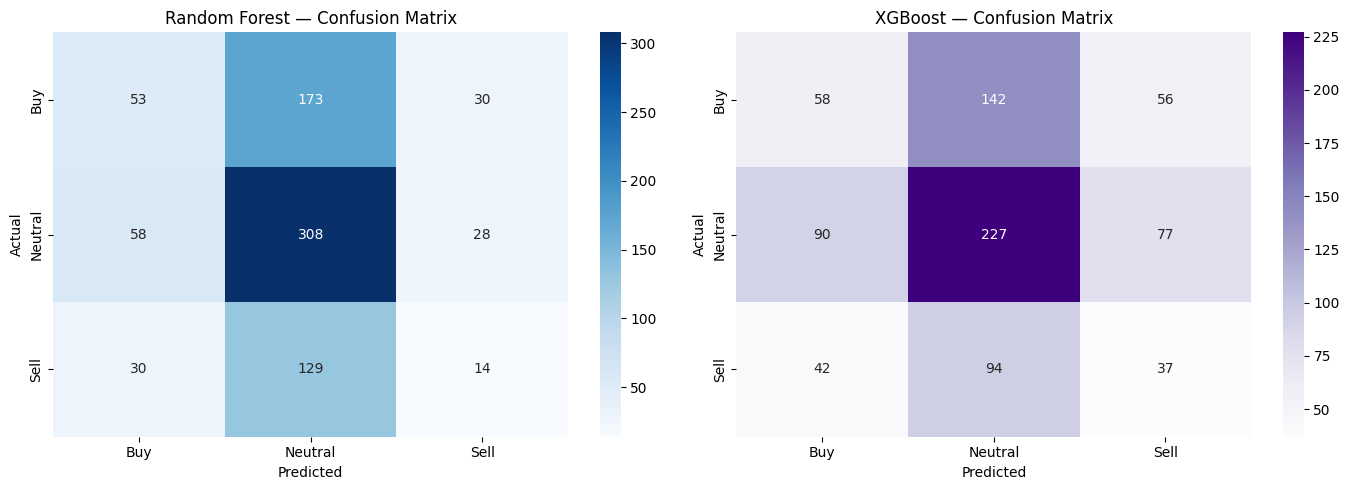

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf  = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('XGBoost — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

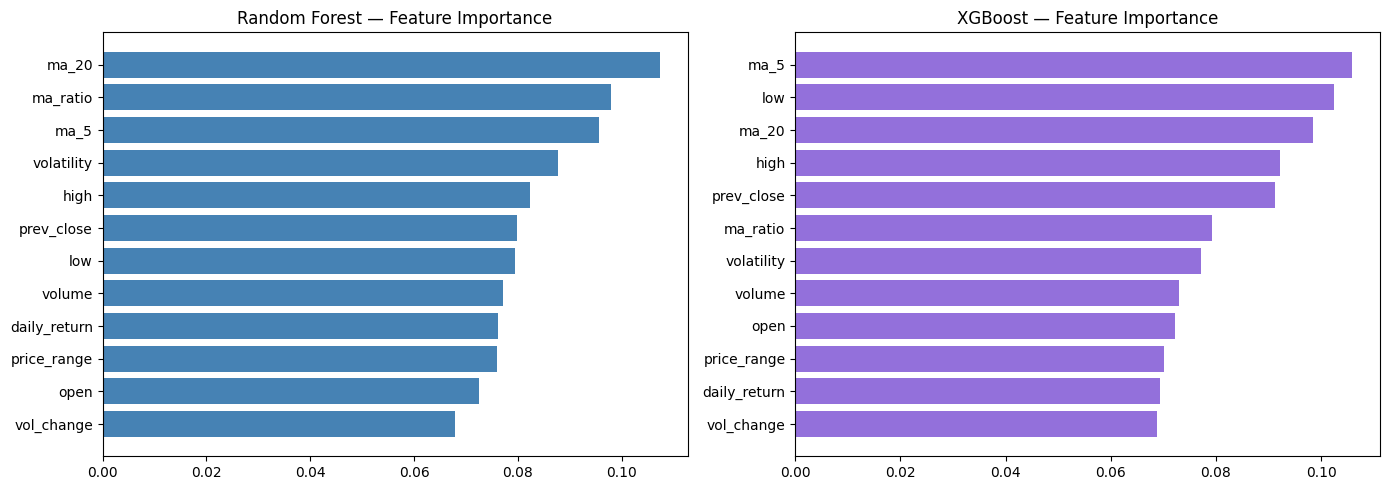

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_rf  = pd.DataFrame({'Feature': feature_cols, 'Importance': rf.feature_importances_}).sort_values('Importance')
imp_xgb = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb.feature_importances_}).sort_values('Importance')

axes[0].barh(imp_rf['Feature'], imp_rf['Importance'], color='steelblue')
axes[0].set_title('Random Forest — Feature Importance')

axes[1].barh(imp_xgb['Feature'], imp_xgb['Importance'], color='mediumpurple')
axes[1].set_title('XGBoost — Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

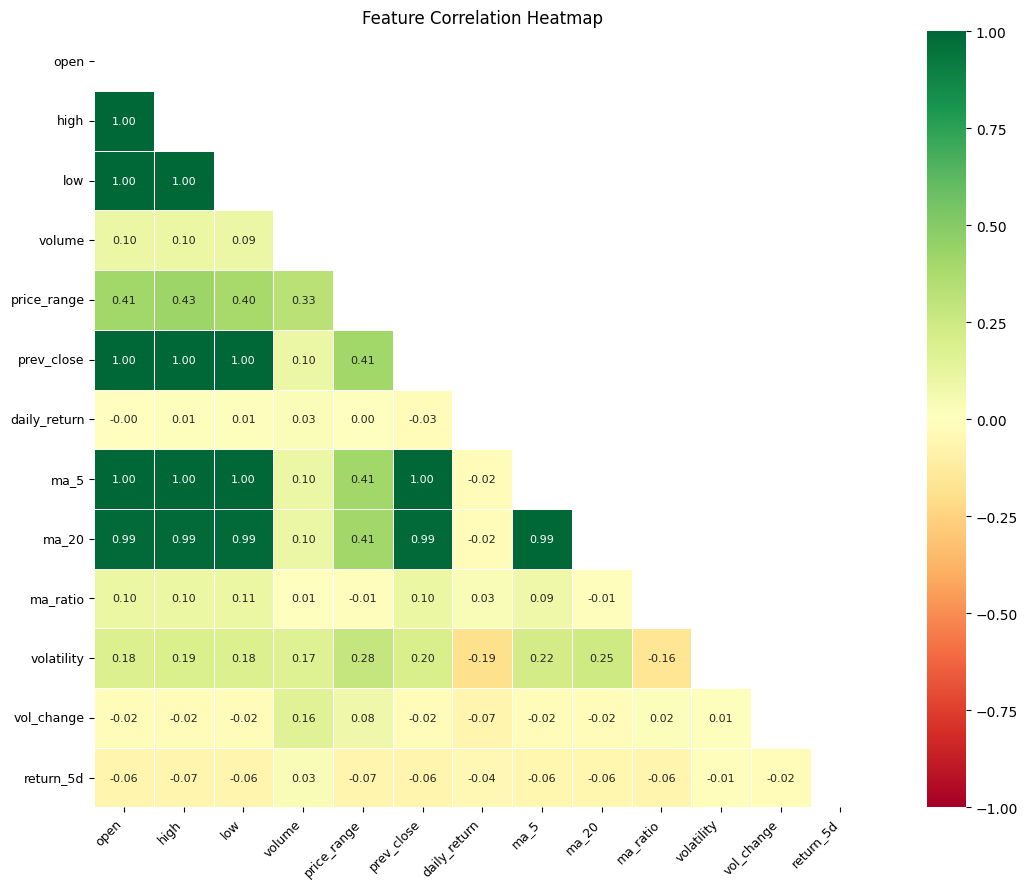

In [14]:
corr = df[feature_cols + ['return_5d']].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, square=True)
plt.title('Feature Correlation Heatmap')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

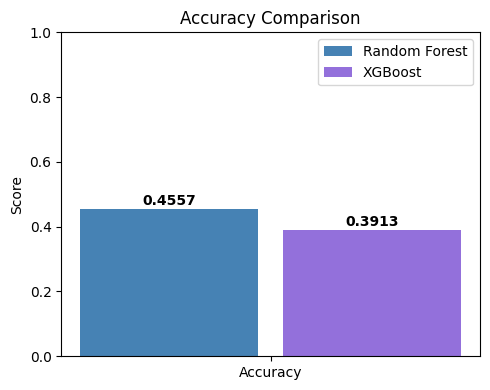

In [15]:
metrics = ['Accuracy']
rf_vals  = [acc_rf]
xgb_vals = [acc_xgb]

x = np.arange(len(metrics))
plt.figure(figsize=(5, 4))
plt.bar(x - 0.2, rf_vals,  0.35, label='Random Forest', color='steelblue')
plt.bar(x + 0.2, xgb_vals, 0.35, label='XGBoost',       color='mediumpurple')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Accuracy Comparison')
plt.legend()
for v, xpos in zip(rf_vals + xgb_vals, [x[0]-0.2, x[0]+0.2]):
    plt.text(xpos, v + 0.01, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
results = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost'],
    'Accuracy': [round(acc_rf, 4), round(acc_xgb, 4)]
})

winner = results.loc[results['Accuracy'].idxmax(), 'Model']

print(results.to_string(index=False))
print(f'\nWinner: {winner}')

        Model  Accuracy
Random Forest    0.4557
      XGBoost    0.3913

Winner: Random Forest
